# Week 2 Checkpoint Assignment: Data Integration and Visualization

**Name:** Joe Doan 
**Student ID:** 16389776  
**Date:** 9 Oct - 2026  

**Points:** 60  
**Suggested time:** 75–90 minutes

This individual exercise assesses your ability to concatenate, merge, validate, summarize, reshape, visualize, and export related datasets with pandas and Matplotlib.


## Submission requirements

Submit all three files:

1. `Lastname_Firstname_Week2_Checkpoint.ipynb`
2. `week2_integrated_cases.csv`
3. `week2_dashboard.png`

Before submitting:

- run the notebook from top to bottom;
- resolve all errors and keep outputs visible;
- answer every written-response prompt in a Markdown cell;
- do not modify the supplied source CSV files;
- do not manually type results that can be calculated from a DataFrame.


## Dataset and allowed tools

Use the four CSV files in the `data` folder. You may use pandas and Matplotlib operations demonstrated in the Week 2 lesson, including:

- `read_csv`, `concat`, `merge`, and `join`;
- `duplicated`, `is_unique`, `value_counts`, and assertions;
- `groupby`, `agg`, `sort_values`, and `pivot`;
- pandas plotting methods and Matplotlib formatting;
- `to_csv` and `savefig`.

Do not install additional packages.


## Setup

Run this cell without changing it. Keep the notebook beside the supplied `data` folder.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 20)

DATA_DIR = Path("content")
PART1_PATH = DATA_DIR / "covid_state_daily_part1.csv"
PART2_PATH = DATA_DIR / "covid_state_daily_part2.csv"
METADATA_PATH = DATA_DIR / "state_metadata.csv"
BENCHMARK_PATH = DATA_DIR / "state_benchmarks.csv"

required_files = [PART1_PATH, PART2_PATH, METADATA_PATH, BENCHMARK_PATH]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing Week 2 data files. Keep the notebook beside the data folder: "
        + ", ".join(missing_files)
    )

print("Setup complete.")


Setup complete.


## Task 1 — Load and inspect the inputs (6 points)

1. Load the two daily files into `part1` and `part2`, parsing `date` as a datetime.
2. Load the lookup files into `state_metadata` and `state_benchmarks`.
3. Create `input_shapes`, a dictionary mapping each variable name to its shape.
4. Display the first three rows of each daily part and print `input_shapes`.
5. Print the minimum and maximum date in each daily part.


In [18]:
# Task 1 solution
part1 = pd.read_csv(PART1_PATH, parse_dates= ['date']) 
part2 = pd.read_csv(PART2_PATH, parse_dates= ['date'])
state_metadata = pd.read_csv(METADATA_PATH)
state_benchmarks = pd.read_csv(BENCHMARK_PATH)

input_shapes = {
    'part1': part1.shape,
    'part2': part2.shape,
    'state_metadata': state_metadata.shape,
    'state_benchmarks': state_benchmarks.shape
}

display(part1.head(3))
display(part2.head(3))
print(f'Part 1 date range: {part1['date'].min()} to {part1['date'].max()}')
print(f'Part 2 date range: {part2['date'].min()} to {part2['date'].max()}')
print("Input shapes:", input_shapes)

,date,state,new_cases,new_tests
0,2021-03-01,NSW,8,12000
1,2021-03-02,NSW,6,12500
2,2021-03-03,NSW,7,13000


,date,state,new_cases,new_tests
0,2021-03-06,NSW,10,14000
1,2021-03-07,NSW,8,13800
2,2021-03-08,NSW,7,14200


Part 1 date range: 2021-03-01 00:00:00 to 2021-03-05 00:00:00
Part 2 date range: 2021-03-06 00:00:00 to 2021-03-10 00:00:00
Input shapes: {'part1': (20, 4), 'part2': (20, 4), 'state_metadata': (5, 4), 'state_benchmarks': (4, 2)}


### Task 1 written response

What does one row in each daily table represent? Why is identifying the grain important before integration?


One row represent for summary figures testing case for one specific date in one specific state. Identifying the grain is critical because: 
1. we can determine the join keys and the relationship type (many-to-one or one-to-many)
2. Avoid duplicate rows that could affect case counts and calculations.
3. Allow us toi validate uniquess and constraints before concatenating with any tables

## Task 2 — Concatenate the daily files (8 points)

1. Create `combined_cases` by concatenating `part1` and `part2` row-wise.
2. Sort by `date` and then `state`; reset the index.
3. Create `duplicate_key_count`, the number of duplicated `date + state` keys.
4. Use an assertion to confirm that the combined row count equals the sum of the two input row counts.
5. Display the first eight rows and print the combined shape and duplicate-key count.


In [3]:
# Task 2 solution
combined_cases = (
    pd.concat([part1,part2], axis = 0, ignore_index= True)
    .sort_values(['date','state'])
    .reset_index(drop = True)
)


print("Expected rows:", len(part1) + len(part2))
print("Combined rows:", len(combined_cases))
assert(len(part1) + len(part2) == len(combined_cases))
duplicate_key_count = int(combined_cases.duplicated(subset = ['state','date']).sum())
display(combined_cases.head(8))
print(f'Combined shape: {combined_cases.shape}')
print(f'Duplicate-key count: {duplicate_key_count}')


Expected rows: 40
Combined rows: 40


,date,state,new_cases,new_tests
0,2021-03-01,NSW,8,12000
1,2021-03-01,QLD,1,7000
2,2021-03-01,VIC,3,9000
3,2021-03-01,WA,0,4500
4,2021-03-02,NSW,6,12500
5,2021-03-02,QLD,0,7100
6,2021-03-02,VIC,2,9200
7,2021-03-02,WA,1,4600


Combined shape: (40, 4)
Duplicate-key count: 0


### Task 2 written response

Explain why `ignore_index=True` does not remove duplicate observations.

Ignore_index just only drop and generate new index for the resulting concatenated dataframe. It does not compare or change the actual data in the rows. To remove duplicate observations, methods .drop_duplicates() must be used.


## Task 3 — Validate keys and merge metadata (10 points)

1. Store whether the metadata key is unique in `metadata_key_is_unique`.
2. Create `integrated` by left-merging `combined_cases` with `state_metadata` on `state`.
3. Require a many-to-one relationship using `validate=` and add the merge indicator.
4. Create `unmatched_rows` containing rows that did not match both tables.
5. Print the indicator counts and the number of unmatched rows.
6. Drop the indicator column from `integrated` after checking it.

Do not continue silently if the metadata key is not unique.


In [17]:
# Task 3 solution
metadata_key_is_unique = state_metadata['state'].is_unique
print(f"Metadata is unique: {metadata_key_is_unique}")
integrated = combined_cases.merge(
    state_metadata,
    how = 'left',
    on = ['state'],
    validate = 'many_to_one',
    indicator=True
)
unmatched_rows = integrated.loc[integrated["_merge"] != "both"]

print(integrated['_merge'].value_counts(dropna=True))
print(f'Number of unmatched rows: {len(unmatched_rows)}')
integrated = integrated.drop(columns="_merge")

Metadata is unique: True
_merge
both          40
left_only      0
right_only     0
Name: count, dtype: int64
Number of unmatched rows: 0


### Task 3 written response

What problem can a duplicated key in the metadata table cause? What does `validate="many_to_one"` protect against?

If the metadata table has duplicate keys, a merge will duplicate daily records. This will lead to artificially inflates total case and test counts.

Validate will asserts that the right table's merge key is unique. If any duplicatate key is detected in the right table, Pandas will raises a merge error. 


## Task 4 — Join benchmarks and calculate rates (8 points)

1. Join `state_benchmarks` to `integrated` using an indexed join on `state`.
2. Create `cases_per_million`, rounded to two decimals.
3. Create `positivity_percent` as `new_cases / new_tests * 100`, rounded to three decimals.
4. Create the Boolean column `above_target` by comparing `cases_per_million` with `target_cases_per_million`.
5. Display the first five rows of the resulting `integrated` DataFrame.


In [ ]:
# Task 4 solution
benchmark_indexed = state_benchmarks.set_index('state')

integrated = integrated.join(
    benchmark_indexed,
    on= 'state',
    validate = 'many_to_one'
)

integrated["cases_per_million"] = (
    integrated["new_cases"] / integrated["population_millions"]
).round(2)
integrated["positivity_percent"] = (
    integrated["new_cases"] / integrated["new_tests"] * 100
).round(3)
integrated["above_target"] = (
    integrated["cases_per_million"] > integrated["target_cases_per_million"]
)

integrated.head()

,date,state,new_cases,new_tests,state_name,region,population_millions,_merge,target_cases_per_million,cases_per_million,positivity_percent,above_target
0,2021-03-01,NSW,8,12000,New South Wales,East,8.17,both,1.0,0.98,0.067,False
1,2021-03-01,QLD,1,7000,Queensland,East,5.18,both,0.3,0.19,0.014,False
2,2021-03-01,VIC,3,9000,Victoria,South,6.68,both,0.6,0.45,0.033,False
3,2021-03-01,WA,0,4500,Western Australia,West,2.67,both,0.4,0.00,0.000,False
4,2021-03-02,NSW,6,12500,New South Wales,East,8.17,both,1.0,0.73,0.048,False


### Task 4 written response

Why can cases per million be more informative than raw case counts? Give one limitation of this comparison.

Cases per million is more informative because it considers the population size of each state. For example, NSW has a much bigger population than WA, so comparing raw case counts is not fair.

One limitation is that this number depends on the testing volume (new_tests). If a state does not test enough people, its cases per million will look low even if there are undetected cases.


## Task 5 — Aggregate and reshape (8 points)

1. Create `state_summary` with one row per state and these columns:
   - `total_cases`: sum of `new_cases`;
   - `average_daily_tests`: mean of `new_tests`, rounded to one decimal;
   - `peak_daily_cases`: maximum of `new_cases`.
2. Sort `state_summary` from highest to lowest `total_cases`.
3. Create `daily_cases_wide` using dates as the index, states as columns, and `new_cases` as values.
4. Display both objects.


In [ ]:
# Task 5 solution
state_summary  = (
    integrated.groupby(['state','state_name', 'region'], as_index=False).agg(
        total_cases = ('new_cases' , 'sum'),
        average_daily_tests = ('new_tests', 'mean'),
        peak_daily_cases = ('new_cases' , 'max')
    ).sort_values(by = ['total_cases'],ascending = False)
)

display(state_summary)


,state,state_name,region,total_cases,average_daily_tests,peak_daily_cases
0,NSW,New South Wales,East,80,13500.0,11
2,VIC,Victoria,South,36,9700.0,6
1,QLD,Queensland,East,13,7530.0,3
3,WA,Western Australia,West,10,4865.0,2


In [12]:
daily_cases_wide = integrated.pivot(
    index="date",
    columns="state",
    values="new_cases",
)
display(daily_cases_wide)


state,NSW,QLD,VIC,WA
date,,,,
2021-03-01,8,1,3,0
2021-03-02,6,0,2,1
2021-03-03,7,2,4,0
2021-03-04,5,1,2,1
2021-03-05,9,1,3,2
2021-03-06,10,2,5,1
2021-03-07,8,1,4,1
2021-03-08,7,0,3,2
2021-03-09,11,3,6,1


### Task 5 written response

Which state has the highest total case count, and what is that total? Explain why `pivot()` requires unique date-state pairs.

NSW has the highest total case count with 80 cases.

pivot() requires unique date-state pairs because each pair needs to fit into exactly one cell in the table. If there are duplicate pairs, Pandas does not know which value to put in that cell and will return an error.


## Task 6 — Create and save a dashboard (12 points)

Create one figure named `fig` with two side-by-side axes:

1. **Left:** a line chart of daily cases for every state using `daily_cases_wide`.
2. **Right:** a horizontal bar chart of total cases by state, ordered from lowest to highest.
3. Give both charts descriptive titles and axis labels.
4. Include a readable legend on the line chart and light grid lines on the relevant numeric axes.
5. Use a figure size of at least 12 by 4 inches and prevent overlapping labels.
6. Save the completed figure as `week2_dashboard.png` at 150 DPI with a tight bounding box.

Do not type chart values manually.


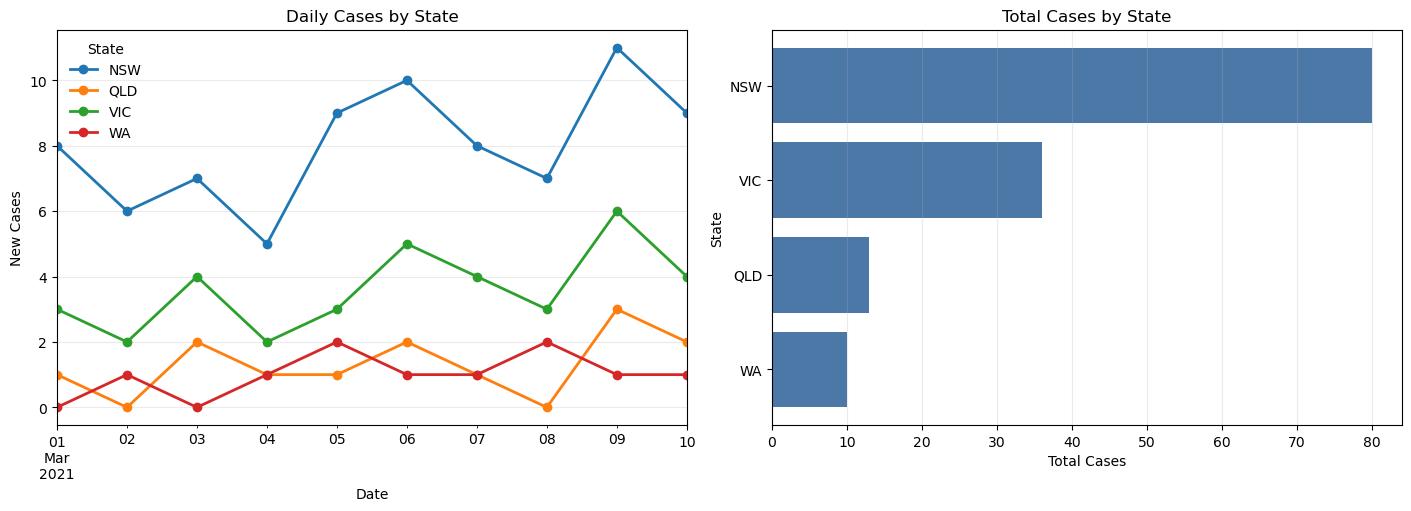

In [13]:
# Task 6 solution
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

daily_cases_wide.plot(ax=axes[0], marker="o", linewidth=2)
axes[0].set(
    title="Daily Cases by State",
    xlabel="Date",
    ylabel="New Cases",
)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(title="State", frameon=False)

bar_data = state_summary.sort_values("total_cases")
axes[1].barh(bar_data["state"], bar_data["total_cases"], color="#4C78A8")
axes[1].set(
    title="Total Cases by State",
    xlabel="Total Cases",
    ylabel="State",
)
axes[1].grid(axis="x", alpha=0.25)

fig.savefig("week2_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


### Task 6 written response

State the analytical question answered by each chart. Identify one design choice you made to improve readability.

The line chart shows how daily cases change over time across different states. 

The bar chart compares the total case counts between states to see which state has the most cases.

To improve readability, I used a horizontal bar chart sorted from lowest to highest, which makes state names easy to read without overlapping.

## Task 7 — Validate, export, and interpret (8 points)

1. Use assertions to confirm:
   - `duplicate_key_count` is zero;
   - `metadata_key_is_unique` is true;
   - `unmatched_rows` is empty;
   - all `new_cases` values are nonnegative;
   - all `new_tests` values are positive;
   - `cases_per_million` contains no missing values.
2. Export `integrated` to `week2_integrated_cases.csv` without the index.
3. Store the export path in `export_path`.
4. Print the final shape and the paths of both submission files.


In [14]:
# Task 7 solution
assert duplicate_key_count == 0
assert metadata_key_is_unique
assert len(unmatched_rows) == 0
assert (integrated["new_cases"] >= 0).all()
assert (integrated["new_tests"] > 0).all()
assert integrated["cases_per_million"].notna().all()

export_path = Path("week2_integrated_cases.csv")
integrated.to_csv(export_path, index=False)

print("Final shape:", integrated.shape)
print("Integrated CSV path:", export_path)
print("Dashboard figure path:", Path("week2_dashboard.png"))


Final shape: (40, 12)
Integrated CSV path: week2_integrated_cases.csv
Dashboard figure path: week2_dashboard.png


### Task 7 written response

In 3–5 sentences, summarize the most important pattern you observed. Include at least one exact value from your output and one limitation of this teaching dataset.

NSW had the highest COVID burden with a total of 80 cases and a peak of 11 daily cases, while WA had the lowest with only 10 cases. Overall, the daily cases across all states stayed fairly stable without sudden spikes. A limitation of this dataset is that it only covers 10 days (March 1 to March 10, 2021), which is too short to analyze long-term trends.

## Submission self-check

Run this cell after completing every task. Passing it confirms that required variables and files exist, but it does not guarantee full credit for correctness, explanations, or chart quality.


In [15]:
required_variables = [
    "part1",
    "part2",
    "state_metadata",
    "state_benchmarks",
    "input_shapes",
    "combined_cases",
    "duplicate_key_count",
    "metadata_key_is_unique",
    "integrated",
    "unmatched_rows",
    "state_summary",
    "daily_cases_wide",
    "fig",
    "export_path",
]

missing_variables = [
    name for name in required_variables if name not in globals()
]

if missing_variables:
    print("Still missing required variables:")
    for name in missing_variables:
        print(" -", name)
else:
    print("All required variables exist.")

csv_path = Path("week2_integrated_cases.csv")
figure_path = Path("week2_dashboard.png")
print("Integrated CSV exists:", csv_path.exists())
print("Dashboard image exists:", figure_path.exists())

if "combined_cases" in globals():
    print(
        "Combined data has unique date-state keys:",
        not combined_cases.duplicated(["date", "state"]).any(),
    )
if "integrated" in globals():
    print("Integrated rows:", len(integrated))


All required variables exist.
Integrated CSV exists: True
Dashboard image exists: True
Combined data has unique date-state keys: True
Integrated rows: 40


## Optional challenge — Audit function (no extra credit required)

Write `audit_merge(left, right, key)` that returns:

- whether the key is unique in the right table;
- the number of unmatched left rows;
- an outer-merge key audit with an indicator column.

Test it with `combined_cases`, `state_metadata`, and `"state"`.


In [16]:
# Optional challenge
def audit_merge(left, right, key):
    right_key_is_unique = right[key].is_unique

    left_merged = left.merge(right[[key]], on=key, how="left", indicator=True)
    unmatched_left_rows = int((left_merged["_merge"] != "both").sum())

    key_audit = (
        left[[key]].drop_duplicates()
        .merge(
            right[[key]].drop_duplicates(),
            on=key,
            how="outer",
            indicator=True,
        )
        .sort_values(key)
        .reset_index(drop=True)
    )

    return right_key_is_unique, unmatched_left_rows, key_audit


is_unique, unmatched_count, key_audit = audit_merge(
    combined_cases, state_metadata, "state"
)

print("Right key is unique:", is_unique)
print("Unmatched left rows:", unmatched_count)
display(key_audit)


Right key is unique: True
Unmatched left rows: 0


,state,_merge
0,NSW,both
1,NT,right_only
2,QLD,both
3,VIC,both
4,WA,both


## Grading rubric

| Area | Points | Full-credit evidence |
|---|---:|---|
| Task 1: Load and inspect | 6 | Correct parsing, shapes, previews, date ranges, and grain explanation |
| Task 2: Concatenate | 8 | Correct row-wise concatenation, order, index, row validation, and duplicate check |
| Task 3: Merge metadata | 10 | Key uniqueness checked, validated merge, indicator audit, and accurate explanation |
| Task 4: Join and derive | 8 | Correct indexed join, rates, target comparison, and interpretation |
| Task 5: Aggregate and reshape | 8 | Accurate grouped summary, sorting, pivot, and evidence-based response |
| Task 6: Visualize | 12 | Two accurate, readable charts calculated from data and saved correctly |
| Task 7: Validate and export | 8 | Assertions pass, CSV exported, files reported, and interpretation completed |
| **Total** | **60** | |

Code should be readable, use meaningful names, and avoid unnecessary repetition.
